**EDA-1**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#Q2.What is the median selling price for bikes in the dataset?

df = pd.read_csv('/BIKE DETAILS.csv')

# Calculate the median selling price
median_selling_price = df['selling_price'].median()
print(f"The median selling price for bikes in the dataset is: {median_selling_price}")

The median selling price for bikes in the dataset is: 45000.0


In [ ]:
#Q1.What is the range of selling prices in the dataset ?

min_selling_price = df['selling_price'].min()
max_selling_price = df['selling_price'].max()

print(f"The minimum selling price is: {min_selling_price}")
print(f"The maximum selling price is: {max_selling_price}")
print(f"The range of selling prices is from {min_selling_price} to {max_selling_price}.")

The minimum selling price is: 5000
The maximum selling price is: 760000
The range of selling prices is from 5000 to 760000.


In [ ]:
#Q3.What is the most common seller type?

most_common_seller_type = df['seller_type'].mode()[0]
print(f"The most common seller type is: {most_common_seller_type}")

The most common seller type is: Individual


In [ ]:
#Q4.How many bikes have driven more than 50,000 kilometers?

bikes_over_50k_km = df[df['km_driven'] > 50000]
num_bikes_over_50k_km = len(bikes_over_50k_km)
print(f"Number of bikes that have driven more than 50,000 kilometers: {num_bikes_over_50k_km}")

Number of bikes that have driven more than 50,000 kilometers: 170


In [ ]:
#Q5.What is the average km_driven value for each ownership type?

average_km_driven_by_owner = df.groupby('owner')['km_driven'].mean()
print("Average kilometers driven by ownership type:")
print(average_km_driven_by_owner)

Average kilometers driven by ownership type:
owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64


In [ ]:
#Q6.What proportion of bikes are from the year 2015 or older?

bikes_2015_or_older = df[df['year'] <= 2015]
num_bikes_2015_or_older = len(bikes_2015_or_older)
total_bikes = len(df)

proportion_2015_or_older = num_bikes_2015_or_older / total_bikes

print(f"Number of bikes from 2015 or older: {num_bikes_2015_or_older}")
print(f"Total number of bikes: {total_bikes}")
print(f"Proportion of bikes from 2015 or older: {proportion_2015_or_older:.2f}")

Number of bikes from 2015 or older: 601
Total number of bikes: 1061
Proportion of bikes from 2015 or older: 0.57


In [ ]:
#Q7.What is the trend of missing values across the dataset?

# Calculate missing values for each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display the missing values info
missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort by percentage
missing_info = missing_info[missing_info['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

if not missing_info.empty:
    print("Trend of missing values across the dataset:")
    display(missing_info)
else:
    print("There are no missing values in the dataset.")

Trend of missing values across the dataset:


,Missing Values,Percentage
ex_showroom_price,435,40.999057


In [ ]:
#Q8.What is the highest ex_showroom_price recorded, and for which bike?

# Drop rows where 'ex_showroom_price' is NaN to ensure accurate max calculation
df_cleaned = df.dropna(subset=['ex_showroom_price'])

# Find the row with the maximum 'ex_showroom_price'
highest_ex_showroom_bike = df_cleaned.loc[df_cleaned['ex_showroom_price'].idxmax()]

# Extract the name and the ex_showroom_price
bike_name = highest_ex_showroom_bike['name']
highest_price = highest_ex_showroom_bike['ex_showroom_price']

print(f"The highest ex_showroom_price recorded is: {highest_price}")
print(f"This price is for the bike: {bike_name}")

The highest ex_showroom_price recorded is: 1278000.0
This price is for the bike: Harley-Davidson Street Bob


In [ ]:
#Q9.What is the total number of bikes listed by each seller type?

bikes_by_seller_type = df['seller_type'].value_counts()
print("Total number of bikes listed by each seller type:")
print(bikes_by_seller_type)

Total number of bikes listed by each seller type:
seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64


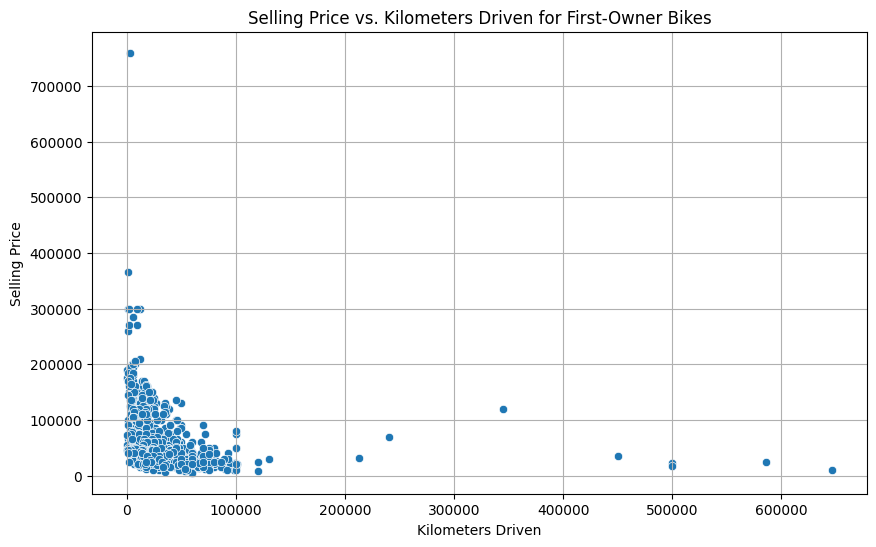

In [ ]:
#Q10.What is the relationship between selling_price and km_driven for first-owner bikes?

# Filter for first-owner bikes
first_owner_bikes = df[df['owner'] == '1st owner']

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='km_driven', y='selling_price', data=first_owner_bikes)
plt.title('Selling Price vs. Kilometers Driven for First-Owner Bikes')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()

In [ ]:
#Q11.Identify and remove outliers in the km_driven column using the IQR method?

Q1_km_driven = df['km_driven'].quantile(0.25)
Q3_km_driven = df['km_driven'].quantile(0.75)
IQR_km_driven = Q3_km_driven - Q1_km_driven

lower_bound_km_driven = Q1_km_driven - 1.5 * IQR_km_driven
upper_bound_km_driven = Q3_km_driven + 1.5 * IQR_km_driven

print(f"Q1 for km_driven: {Q1_km_driven}")
print(f"Q3 for km_driven: {Q3_km_driven}")
print(f"IQR for km_driven: {IQR_km_driven}")
print(f"Lower bound for km_driven: {lower_bound_km_driven}")
print(f"Upper bound for km_driven: {upper_bound_km_driven}")

Q1 for km_driven: 13000.0
Q3 for km_driven: 40000.0
IQR for km_driven: 27000.0
Lower bound for km_driven: -27500.0
Upper bound for km_driven: 80500.0


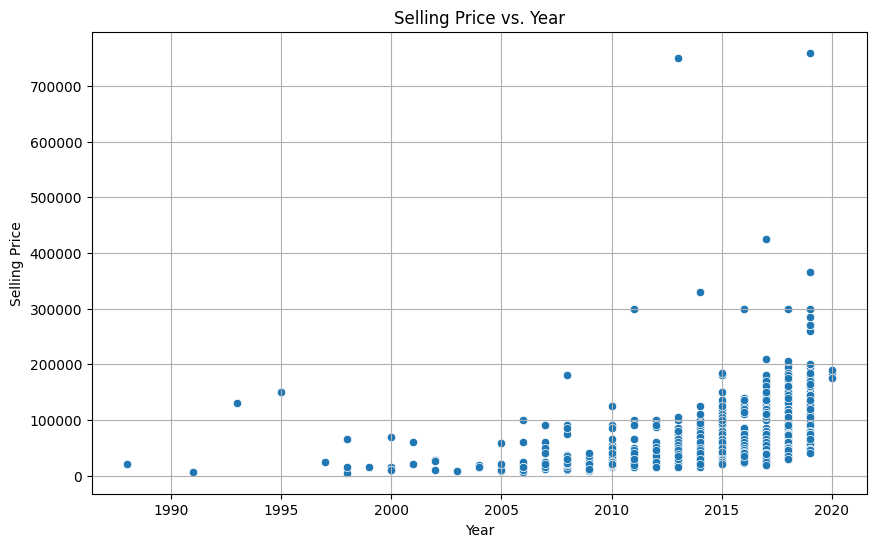

In [ ]:
#Q12.Perform a bivariate analysis to visualize the relationship between year and selling_price.

plt.figure(figsize=(10, 6))
sns.scatterplot(x='year', y='selling_price', data=df)
plt.title('Selling Price vs. Year')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()

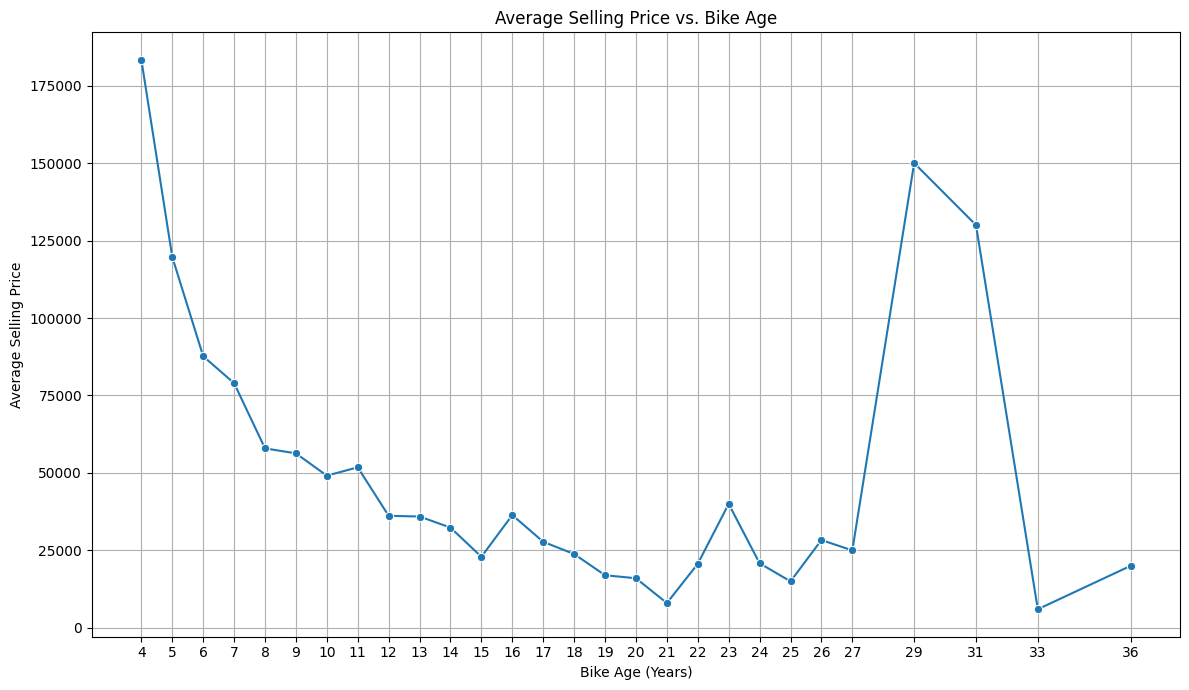

Plot showing average selling price by bike age has been generated.


In [ ]:
#Q13.What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)?
plt.figure(figsize=(12, 7))
sns.lineplot(x=average_price_by_age.index, y=average_price_by_age.values, marker='o')
plt.title('Average Selling Price vs. Bike Age')
plt.xlabel('Bike Age (Years)')
plt.ylabel('Average Selling Price')
plt.grid(True)
plt.xticks(average_price_by_age.index)
plt.tight_layout()
plt.show()
print("Plot showing average selling price by bike age has been generated.")

In [ ]:
#Q14.What is the average depreciation in selling price based on the bike's age (current year - manufacturing year) Which bike names are priced significantly above the average price for their manufacturing year?

df_merged = df.merge(average_price_per_year.rename('avg_yearly_price'), on='year', how='left')
df_merged = df_merged.merge(std_dev_price_per_year.rename('std_yearly_price'), on='year', how='left')

# Calculate the threshold for high-priced bikes
df_merged['upper_threshold'] = df_merged['avg_yearly_price'] + 1.5 * df_merged['std_yearly_price']

# Identify bikes with selling_price significantly above their yearly average
high_priced_bikes = df_merged[df_merged['selling_price'] > df_merged['upper_threshold']]

# Select relevant columns for the high-priced bikes
result = high_priced_bikes[['name', 'year', 'selling_price']]

print("Bikes with selling price significantly above their yearly average:")
print(result)


Bikes with selling price significantly above their yearly average:
                                     name  year  selling_price
7    Royal Enfield Bullet 350 [2007-2011]  2008         180000
13                          Yamaha YZF R3  2019         365000
37                         Honda CBR-250R  2016         120000
42                           KTM 390 Duke  2017         175000
52              Royal Enfield Electra 5 S  2010          90000
..                                    ...   ...            ...
924             Royal Enfield Thunder 500  2018         175000
930                        Hyosung GT250R  2016         135000
931             Royal Enfield Thunder 350  2015         125000
936                         KTM 390 Duke   2016         115000
940             Royal Enfield Classic 350  2015         110000

[73 rows x 3 columns]


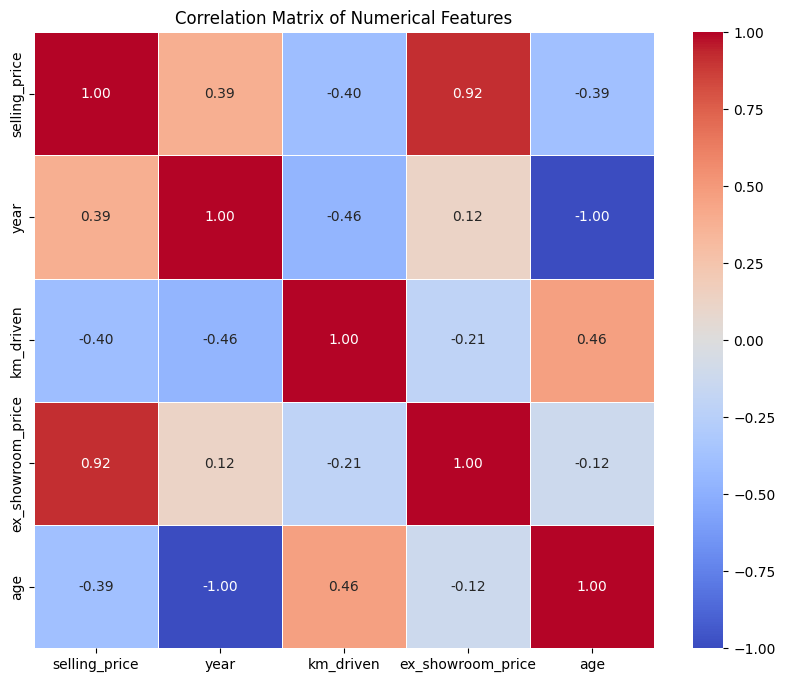

In [ ]:
#Q15.Develop a correlation matrix for numeric columns and visualize it using a heatmap.

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**EDA-2**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#Q1.What is the average selling price of cars for each dealer, and how does it compare across different dealers?

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Display the first 5 rows and column information
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(df.info())



# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Display the first 5 rows and column information
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(df.info())




| Car_id       | Date     | Customer Name   | Gender   | Annual Income   | Dealer_Name                         | Company   | Model      | Engine                    | Transmission   | Color      | Price ($)   | Dealer_No    | Body Style   | Phone   | Dealer_Region   |
|:-------------|:---------|:----------------|:---------|:----------------|:------------------------------------|:----------|:-----------|:--------------------------|:---------------|:-----------|:------------|:-------------|:-------------|:--------|:----------------|
| C_CND_000001 | 1/2/2022 | Geraldine       | Male     | 13500           | Buddy Storbeck's Diesel Service Inc | Ford      | Expedition | DoubleÂ Overhead Camshaft | Auto           | Black      | 26000       | 06457-3834   | SUV          | 8264678 | Middletown      |
| C_CND_000002 | 1/2/2022 | Gia             | Male     | 1480000         | C & M Motors Inc                    | Dodge     | Durango    | DoubleÂ Overhead Camshaft | Auto           | Black      | 

In [ ]:
#Q2.Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?

import pandas as pd

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Group by 'Company' and calculate the standard deviation of 'Price ($)'
price_variation_by_company = df.groupby('Company')['Price ($)'].std().reset_index()

# Rename the aggregated column
price_variation_by_company.columns = ['Company', 'Price_Standard_Deviation']

# Sort the results in descending order of standard deviation
price_variation_by_company = price_variation_by_company.sort_values(by='Price_Standard_Deviation', ascending=False)

# Display the top 5 companies with the highest price variation
print("Top 5 Companies by Price Variation (Standard Deviation):")
print(price_variation_by_company.head(5).to_markdown(index=False, numalign="left", stralign="left"))

# Get the top company for the final answer
top_company = price_variation_by_company.iloc[0]['Company']
top_std_dev = price_variation_by_company.iloc[0]['Price_Standard_Deviation']

# Additionally, calculate the mean price for the top company to provide more context
mean_price_top_company = df[df['Company'] == top_company]['Price ($)'].mean()

print(f"\nDetails for the company with the highest variation: {top_company}")
print(f"Standard Deviation: {top_std_dev:,.2f}")
print(f"Mean Price: {mean_price_top_company:,.2f}")

Top 5 Companies by Price Variation (Standard Deviation):
| Company   | Price_Standard_Deviation   |
|:----------|:---------------------------|
| Lincoln   | 19658.1                    |
| Saab      | 19653.7                    |
| Cadillac  | 19517.1                    |
| Plymouth  | 19066                      |
| Lexus     | 17852.9                    |

Details for the company with the highest variation: Lincoln
Standard Deviation: 19,658.05
Mean Price: 31,407.04


In [ ]:
#Q3.What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Group by 'Transmission' and calculate descriptive statistics for 'Price ($)'
price_stats_by_transmission = df.groupby('Transmission')['Price ($)'].describe()

# Calculate the Interquartile Range (IQR)
price_stats_by_transmission['IQR'] = price_stats_by_transmission['75%'] - price_stats_by_transmission['25%']

# Sort the results by IQR in descending order
iqr_comparison = price_stats_by_transmission[['count', 'mean', 'std', 'min', 'max', '25%', '50%', '75%', 'IQR']].sort_values(by='IQR', ascending=False)

# Display the comparison table
print("Price Distribution Statistics by Transmission Type (sorted by IQR):")
print(iqr_comparison.to_markdown(numalign="left", stralign="left"))

# Create a box plot to visualize the distribution
import altair as alt

# Altair boxplot of Price ($) for each Transmission type
chart = alt.Chart(df).mark_boxplot(extent='min-max', size=50).encode(
    x=alt.X('Transmission', title='Transmission Type'),
    y=alt.Y('Price ($)', title='Price ($)', axis=alt.Axis(format='$,.0f')),
    tooltip=['Transmission', alt.Tooltip('Price ($)', title='Price', format='$,.0f')]
).properties(
    title='Distribution of Car Prices by Transmission Type'
).interactive()

# Save the chart
chart.save('price_distribution_by_transmission_boxplot.json')

Price Distribution Statistics by Transmission Type (sorted by IQR):
| Transmission   | count   | mean    | std     | min   | max   | 25%   | 50%   | 75%   | IQR   |
|:---------------|:--------|:--------|:--------|:------|:------|:------|:------|:------|:------|
| Manual         | 11335   | 27914.7 | 15862.9 | 1700  | 85800 | 17000 | 22001 | 34000 | 17000 |
| Auto           | 12571   | 28248.5 | 13747.1 | 1200  | 75700 | 19000 | 24000 | 35500 | 16500 |


In [ ]:
#Q4.What is the distribution of car prices across different regions?

import pandas as pd
import altair as alt

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Group by 'Dealer_Region' and calculate descriptive statistics for 'Price ($)'
price_stats_by_region = df.groupby('Dealer_Region')['Price ($)'].describe()

# Calculate the Interquartile Range (IQR)
price_stats_by_region['IQR'] = price_stats_by_region['75%'] - price_stats_by_region['25%']

# Sort the results by the mean price in descending order
stats_comparison = price_stats_by_region[['count', 'mean', 'std', 'min', 'max', '25%', '50%', '75%', 'IQR']].sort_values(by='mean', ascending=False)

# Display the comparison table
print("Price Distribution Statistics by Dealer Region (sorted by Mean Price):")
print(stats_comparison.to_markdown(numalign="left", stralign="left"))

# Create a box plot to visualize the distribution
# Altair boxplot of Price ($) for each Dealer_Region
chart = alt.Chart(df).mark_boxplot(extent='min-max', size=50).encode(
    x=alt.X('Dealer_Region', title='Dealer Region'),
    y=alt.Y('Price ($)', title='Price ($)', axis=alt.Axis(format='$,.0f')),
    tooltip=['Dealer_Region', alt.Tooltip('Price ($)', title='Price', format='$,.0f')]
).properties(
    title='Distribution of Car Prices by Dealer Region'
).interactive()

# Save the chart
chart.save('price_distribution_by_region_boxplot.json')

Price Distribution Statistics by Dealer Region (sorted by Mean Price):
| Dealer_Region   | count   | mean    | std     | min   | max   | 25%     | 50%   | 75%   | IQR     |
|:----------------|:--------|:--------|:--------|:------|:------|:--------|:------|:------|:--------|
| Austin          | 4135    | 28341.6 | 14903.9 | 9000  | 85601 | 18001   | 23801 | 35001 | 17000   |
| Aurora          | 3130    | 28334.6 | 15026.2 | 9000  | 85800 | 18001   | 23000 | 35000 | 16999   |
| Greenville      | 3128    | 28180.8 | 15101.5 | 1200  | 85200 | 18001   | 22500 | 34500 | 16499   |
| Pasco           | 3131    | 28119   | 14659.3 | 9000  | 85600 | 18500.5 | 23000 | 34000 | 15499.5 |
| Scottsdale      | 3433    | 27955   | 14902.9 | 1450  | 85001 | 18000   | 22600 | 33500 | 15500   |
| Middletown      | 3128    | 27856.3 | 14619.8 | 1700  | 85300 | 18000   | 22750 | 34000 | 16000   |
| Janesville      | 3821    | 27833.4 | 14345   | 4300  | 85400 | 18001   | 23000 | 34000 | 15999   |


In [ ]:
#Q5.What is the distribution of cars based on body styles?

import pandas as pd
import altair as alt

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Count the occurrences of each 'Body Style'
body_style_counts = df['Body Style'].value_counts().reset_index()
body_style_counts.columns = ['Body_Style', 'Count']

# Calculate the percentage distribution
total_cars = body_style_counts['Count'].sum()
body_style_counts['Percentage'] = (body_style_counts['Count'] / total_cars) * 100

# Sort the results in descending order of Count
body_style_distribution = body_style_counts.sort_values(by='Count', ascending=False)

# Display the distribution table
print("Distribution of Cars by Body Style:")
print(body_style_distribution.to_markdown(index=False, numalign="left", stralign="left"))

# Create a bar chart to visualize the distribution
chart = alt.Chart(body_style_distribution).mark_bar().encode(
    x=alt.X('Body_Style', title='Body Style', sort='-y'), # Sort by count (y-axis)
    y=alt.Y('Count', title='Number of Cars'),
    tooltip=['Body_Style', 'Count', alt.Tooltip('Percentage', format='.1f', title='Percentage (%)')]
).properties(
    title='Distribution of Cars by Body Style'
).interactive()

# Save the chart
chart.save('car_distribution_by_body_style_barchart.json')

Distribution of Cars by Body Style:
| Body_Style   | Count   | Percentage   |
|:-------------|:--------|:-------------|
| SUV          | 6374    | 26.6628      |
| Hatchback    | 6128    | 25.6337      |
| Sedan        | 4488    | 18.7735      |
| Passenger    | 3945    | 16.5021      |
| Hardtop      | 2971    | 12.4278      |


In [ ]:
#Q6.How does the average selling price of cars vary by customer gender and annual income?

import pandas as pd

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# 1. Analysis of Average Price by Gender
avg_price_by_gender = df.groupby('Gender')['Price ($)'].mean().reset_index()
avg_price_by_gender.columns = ['Gender', 'Average_Price']
avg_price_by_gender['Average_Price'] = avg_price_by_gender['Average_Price'].round(2)
print("--- Average Selling Price by Gender ---")
print(avg_price_by_gender.to_markdown(index=False, numalign="left", stralign="left"))

# 2. Analysis of Average Price by Annual Income (need to bin the income)
# Get descriptive statistics for 'Annual Income' to determine binning strategy
income_stats = df['Annual Income'].describe(percentiles=[.25, .5, .75])
print("\n--- Annual Income Descriptive Statistics ---")
print(income_stats.to_markdown(numalign="left", stralign="left"))

# Define income bins based on quartiles:
# Q1: < 25% (Low)
# Q2: 25% to 50% (Medium)
# Q3: 50% to 75% (High)
# Q4: > 75% (Very High)
q1 = income_stats['25%']
q2 = income_stats['50%']
q3 = income_stats['75%']

bins = [df['Annual Income'].min(), q1, q2, q3, df['Annual Income'].max()]
labels = ['Low ($0 - Q1)', 'Medium (Q1 - Q2)', 'High (Q2 - Q3)', 'Very High (Q3 - Max)']

# Create income categories
df['Income_Category'] = pd.cut(df['Annual Income'], bins=bins, labels=labels, include_lowest=True)

# Calculate average price by income category
avg_price_by_income = df.groupby('Income_Category', observed=False)['Price ($)'].mean().reset_index()
avg_price_by_income.columns = ['Income_Category', 'Average_Price']
avg_price_by_income['Average_Price'] = avg_price_by_income['Average_Price'].round(2)

print("\n--- Average Selling Price by Annual Income Category ---")
print(avg_price_by_income.to_markdown(index=False, numalign="left", stralign="left"))

--- Average Selling Price by Gender ---
| Gender   | Average_Price   |
|:---------|:----------------|
| Female   | 28277.3         |
| Male     | 28039.4         |

--- Annual Income Descriptive Statistics ---
|       | Annual Income   |
|:------|:----------------|
| count | 23906           |
| mean  | 830840          |
| std   | 720006          |
| min   | 10080           |
| 25%   | 386000          |
| 50%   | 735000          |
| 75%   | 1.17575e+06     |
| max   | 1.12e+07        |

--- Average Selling Price by Annual Income Category ---
| Income_Category      | Average_Price   |
|:---------------------|:----------------|
| Low ($0 - Q1)        | 27954.3         |
| Medium (Q1 - Q2)     | 27974.4         |
| High (Q2 - Q3)       | 28288.7         |
| Very High (Q3 - Max) | 28144.1         |


In [ ]:
#Q7.What is the distribution of car prices by region, and how does the number of cars sold vary by region?

import pandas as pd

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Group by 'Dealer_Region' and count the number of cars sold
sales_by_region = df.groupby('Dealer_Region').size().reset_index(name='Number of Cars Sold')

# Sort the results by the number of cars sold in descending order
sales_by_region = sales_by_region.sort_values(by='Number of Cars Sold', ascending=False)

# Display the table
print("Number of Cars Sold by Dealer Region:")
print(sales_by_region.to_markdown(index=False, numalign="left", stralign="left"))

Number of Cars Sold by Dealer Region:
| Dealer_Region   | Number of Cars Sold   |
|:----------------|:----------------------|
| Austin          | 4135                  |
| Janesville      | 3821                  |
| Scottsdale      | 3433                  |
| Pasco           | 3131                  |
| Aurora          | 3130                  |
| Greenville      | 3128                  |
| Middletown      | 3128                  |


In [ ]:
#Q8.How does the average car price differ between cars with different engine sizes?

import pandas as pd

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Group by 'Engine' and calculate the average 'Price ($)'
avg_price_by_engine = df.groupby('Engine')['Price ($)'].mean().reset_index()

# Rename the aggregated column and round the average price
avg_price_by_engine.columns = ['Engine_Type', 'Average_Price']
avg_price_by_engine['Average_Price'] = avg_price_by_engine['Average_Price'].round(2)

# Sort the results in descending order of average price
avg_price_by_engine = avg_price_by_engine.sort_values(by='Average_Price', ascending=False)

# Display the result table
print("Average Selling Price by Engine Type:")
print(avg_price_by_engine.to_markdown(index=False, numalign="left", stralign="left"))

Average Selling Price by Engine Type:
| Engine_Type               | Average_Price   |
|:--------------------------|:----------------|
| DoubleÂ Overhead Camshaft | 28248.5         |
| Overhead Camshaft         | 27914.7         |


In [ ]:
#Q9.How do car prices vary based on the customer’s annual income bracket?

import pandas as pd
import altair as alt

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Get descriptive statistics for 'Annual Income' to determine binning strategy
income_stats = df['Annual Income'].describe(percentiles=[.25, .5, .75])

# Define income bins based on quartiles:
q1 = income_stats['25%']
q2 = income_stats['50%']
q3 = income_stats['75%']

bins = [df['Annual Income'].min(), q1, q2, q3, df['Annual Income'].max()]
labels = ['Low (Q1)', 'Medium (Q2)', 'High (Q3)', 'Very High (Q4)']

# Create income categories
df['Income_Category'] = pd.cut(df['Annual Income'], bins=bins, labels=labels, include_lowest=True)

# Calculate average price by income category
avg_price_by_income = df.groupby('Income_Category', observed=False)['Price ($)'].mean().reset_index()
avg_price_by_income.columns = ['Income_Category', 'Average_Price']
avg_price_by_income['Average_Price'] = avg_price_by_income['Average_Price'].round(2)

# Display the data for the answer table
print("Average Selling Price by Annual Income Category:")
print(avg_price_by_income.to_markdown(index=False, numalign="left", stralign="left"))

# Create a bar chart to visualize the distribution
chart = alt.Chart(avg_price_by_income).mark_bar().encode(
    x=alt.X('Income_Category', title='Annual Income Bracket', sort=labels), # Ensure correct sorting
    y=alt.Y('Average_Price', title='Average Selling Price ($)', axis=alt.Axis(format='$,.0f')),
    tooltip=['Income_Category', alt.Tooltip('Average_Price', format='$,.2f', title='Avg Price')]
).properties(
    title='Average Car Price by Customer Annual Income Bracket'
).interactive()

# Save the chart
chart.save('avg_price_by_income_barchart.json')

Average Selling Price by Annual Income Category:
| Income_Category   | Average_Price   |
|:------------------|:----------------|
| Low (Q1)          | 27954.3         |
| Medium (Q2)       | 27974.4         |
| High (Q3)         | 28288.7         |
| Very High (Q4)    | 28144.1         |


In [ ]:
#Q10.What are the top 5 car models with the highest number of sales, and how does their price distribution look?

import pandas as pd
import altair as alt

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# 1. Identify Top 5 Models by sales count
top_5_models = df['Model'].value_counts().nlargest(5).reset_index()
top_5_models.columns = ['Model', 'Sales_Count']

# Display the top 5 models sales count
print("Top 5 Car Models by Number of Sales:")
print(top_5_models.to_markdown(index=False, numalign="left", stralign="left"))

# Get the list of top 5 models
top_5_list = top_5_models['Model'].tolist()

# 2. Filter Data for top 5 models
df_top_5 = df[df['Model'].isin(top_5_list)]

# 3. Analyze Price Distribution for the top 5 models
price_stats_top_5 = df_top_5.groupby('Model')['Price ($)'].describe()
price_stats_top_5['IQR'] = price_stats_top_5['75%'] - price_stats_top_5['25%']

# Select and format relevant columns, sort by mean price for comparison
price_distribution = price_stats_top_5[['count', 'mean', '50%', 'std', 'min', 'max', '25%', '75%', 'IQR']].sort_values(by='mean', ascending=False)
price_distribution['mean'] = price_distribution['mean'].round(2)
price_distribution['std'] = price_distribution['std'].round(2)

# Display the price distribution statistics
print("\nPrice Distribution Statistics for Top 5 Car Models (sorted by Mean Price):")
print(price_distribution.to_markdown(numalign="left", stralign="left"))

# 4. Visualize the Price Distribution
chart = alt.Chart(df_top_5).mark_boxplot(extent='min-max').encode(
    x=alt.X('Model', title='Car Model', sort=alt.EncodingSortField(field="Price ($)", op="mean", order='descending')),
    y=alt.Y('Price ($)', title='Selling Price ($)', axis=alt.Axis(format='$,.0f')),
    tooltip=['Model', alt.Tooltip('Price ($)', title='Price', format='$,.0f')]
).properties(
    title='Price Distribution of Top 5 Selling Car Models'
).interactive()

# Save the chart
chart.save('top_5_models_price_distribution_boxplot.json')

Top 5 Car Models by Number of Sales:
| Model      | Sales_Count   |
|:-----------|:--------------|
| Diamante   | 418           |
| Prizm      | 411           |
| Silhouette | 411           |
| Passat     | 391           |
| Ram Pickup | 383           |

Price Distribution Statistics for Top 5 Car Models (sorted by Mean Price):
| Model      | count   | mean    | 50%   | std     | min   | max   | 25%   | 75%   | IQR   |
|:-----------|:--------|:--------|:------|:--------|:------|:------|:------|:------|:------|
| Silhouette | 411     | 29858.5 | 25000 | 17940.6 | 12000 | 60750 | 14001 | 34500 | 20499 |
| Ram Pickup | 383     | 27820.9 | 21000 | 13297.6 | 16000 | 57750 | 19000 | 39300 | 20300 |
| Prizm      | 411     | 22838.5 | 22000 | 8012.53 | 15000 | 44700 | 16000 | 25000 | 9000  |
| Diamante   | 418     | 22268.3 | 19001 | 9770.77 | 12000 | 49801 | 18000 | 22000 | 4000  |
| Passat     | 391     | 19600.7 | 20000 | 8218.52 | 9000  | 32501 | 12001 | 27001 | 15000 |


In [ ]:
#Q11.How does car price vary with engine size across different car colors, and which colors have the highest price variation?

import pandas as pd

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# 1. Average Price Variation by Engine Type and Color
avg_price_engine_color = df.groupby(['Engine', 'Color'])['Price ($)'].mean().reset_index()
avg_price_engine_color.columns = ['Engine_Type', 'Color', 'Average_Price']
avg_price_engine_color['Average_Price'] = avg_price_engine_color['Average_Price'].round(2)
# Sort to easily see differences
avg_price_engine_color_sorted = avg_price_engine_color.sort_values(by='Average_Price', ascending=False)

# Display the top 10 combinations for price analysis
print("--- Top 10 Average Prices by Engine Type and Color ---")
print(avg_price_engine_color_sorted.head(10).to_markdown(index=False, numalign="left", stralign="left"))

# 2. Highest Price Variation (Standard Deviation) by Color
price_variation_by_color = df.groupby('Color')['Price ($)'].std().reset_index()
price_variation_by_color.columns = ['Color', 'Price_Standard_Deviation']
price_variation_by_color['Price_Standard_Deviation'] = price_variation_by_color['Price_Standard_Deviation'].round(2)

# Sort the results in descending order of standard deviation
top_5_variation = price_variation_by_color.sort_values(by='Price_Standard_Deviation', ascending=False).head(5)

# Display the top 5 colors by price variation
print("\n--- Top 5 Colors with Highest Price Variation (Standard Deviation) ---")
print(top_5_variation.to_markdown(index=False, numalign="left", stralign="left"))

--- Top 10 Average Prices by Engine Type and Color ---
| Engine_Type               | Color      | Average_Price   |
|:--------------------------|:-----------|:----------------|
| Overhead Camshaft         | Black      | 31733           |
| DoubleÂ Overhead Camshaft | Pale White | 30348           |
| Overhead Camshaft         | Red        | 30153.4         |
| DoubleÂ Overhead Camshaft | Red        | 27434.4         |
| DoubleÂ Overhead Camshaft | Black      | 25766.5         |
| Overhead Camshaft         | Pale White | 24327.8         |

--- Top 5 Colors with Highest Price Variation (Standard Deviation) ---
| Color      | Price_Standard_Deviation   |
|:-----------|:---------------------------|
| Red        | 15519.4                    |
| Black      | 15286.1                    |
| Pale White | 14077.4                    |


In [ ]:
#Q12. Is there any seasonal trend in car sales based on the date of sale?

import pandas as pd
import altair as alt

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# 1. Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 2. Extract Month and Month Name
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

# 3. Calculate the total number of sales per month
monthly_sales = df.groupby(['Month', 'Month_Name']).size().reset_index(name='Total_Sales')

# 4. Sort the results by month number
monthly_sales = monthly_sales.sort_values(by='Month', ascending=True)

# 5. Display the monthly sales table
print("Total Car Sales by Month:")
print(monthly_sales[['Month_Name', 'Total_Sales']].to_markdown(index=False, numalign="left", stralign="left"))

# 6. Create a bar chart for monthly sales trend
# Define the order for the months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

chart = alt.Chart(monthly_sales).mark_bar().encode(
    x=alt.X('Month_Name', title='Month', sort=month_order),
    y=alt.Y('Total_Sales', title='Total Car Sales'),
    tooltip=['Month_Name', 'Total_Sales']
).properties(
    title='Seasonal Trend in Car Sales by Month'
).interactive()

# Save the chart
chart.save('monthly_car_sales_trend_barchart.json')

Total Car Sales by Month:
| Month_Name   | Total_Sales   |
|:-------------|:--------------|
| Jan          | 790           |
| Feb          | 735           |
| Mar          | 1535          |
| Apr          | 1655          |
| May          | 1895          |
| Jun          | 1715          |
| Jul          | 1725          |
| Aug          | 1705          |
| Sep          | 3305          |
| Oct          | 1830          |
| Nov          | 3470          |
| Dec          | 3546          |


In [ ]:
#Q13.How does the car price distribution change when considering different combinations of body style and transmission type?

import pandas as pd
import altair as alt

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Group by 'Body Style' and 'Transmission' and calculate descriptive statistics for 'Price ($)'
price_stats_combo = df.groupby(['Body Style', 'Transmission'])['Price ($)'].describe()

# Calculate the Interquartile Range (IQR)
price_stats_combo['IQR'] = price_stats_combo['75%'] - price_stats_combo['25%']

# Select and format relevant columns, sort by mean price for comparison
price_distribution_combo = price_stats_combo[['count', 'mean', '50%', 'std', 'min', 'max', '25%', '75%', 'IQR']].sort_values(by='mean', ascending=False)
price_distribution_combo['mean'] = price_distribution_combo['mean'].round(2)
price_distribution_combo['std'] = price_distribution_combo['std'].round(2)

# Display the price distribution statistics
print("Price Distribution Statistics by Body Style and Transmission:")
print(price_distribution_combo.to_markdown(numalign="left", stralign="left"))

# Create a box plot to visualize the distribution
# Altair boxplot of Price ($) for each combination
chart = alt.Chart(df).mark_boxplot(extent='min-max', size=30).encode(
    # 'Body Style' for the x-axis, 'Transmission' for column separation
    x=alt.X('Body Style', title='Body Style'),
    column=alt.Column('Transmission', header=alt.Header(titleOrient="bottom", labelOrient="bottom")),
    y=alt.Y('Price ($)', title='Selling Price ($)', axis=alt.Axis(format='$,.0f')),
    tooltip=['Body Style', 'Transmission', alt.Tooltip('Price ($)', title='Price', format='$,.0f')]
).properties(
    title='Price Distribution by Body Style and Transmission Type'
).interactive()

# Save the chart
chart.save('price_distribution_combo_boxplot.json')

Price Distribution Statistics by Body Style and Transmission:
|                         | count   | mean    | 50%   | std     | min   | max   | 25%     | 75%   | IQR     |
|:------------------------|:--------|:--------|:------|:--------|:------|:------|:--------|:------|:--------|
| ('Hardtop', 'Auto')     | 1408    | 31520.2 | 27000 | 13687.8 | 12000 | 75501 | 21001   | 43125 | 22124   |
| ('Sedan', 'Auto')       | 2599    | 29955.3 | 26000 | 14310.9 | 12000 | 69980 | 19000   | 39500 | 20500   |
| ('Sedan', 'Manual')     | 1889    | 29664.3 | 25000 | 15440.1 | 11000 | 69700 | 19001   | 36600 | 17599   |
| ('Passenger', 'Manual') | 1925    | 28969.5 | 22000 | 18523.7 | 10000 | 85800 | 16001   | 37000 | 20999   |
| ('Passenger', 'Auto')   | 2020    | 28915.8 | 25000 | 13946.5 | 9000  | 69801 | 19000   | 38000 | 19000   |
| ('Hatchback', 'Manual') | 2670    | 28702.5 | 23000 | 16284   | 1700  | 85600 | 17000   | 36001 | 19001   |
| ('SUV', 'Auto')         | 3086    | 27501.4 | 25000 | 13

In [ ]:
#Q14.What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?

import pandas as pd

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# 1. Calculate the Pearson correlation between Car Price and Annual Income
correlation = df['Price ($)'].corr(df['Annual Income'])

print(f"--- Pearson Correlation (Car Price vs. Annual Income) ---")
print(f"Correlation Coefficient: {correlation:.4f}")

# 2. Analyze the Interaction between Car Price, Engine Type, and Annual Income
# Get descriptive statistics for 'Annual Income' to determine binning strategy
income_stats = df['Annual Income'].describe(percentiles=[.25, .5, .75])
q1 = income_stats['25%']
q2 = income_stats['50%']
q3 = income_stats['75%']

bins = [df['Annual Income'].min(), q1, q2, q3, df['Annual Income'].max()]
labels = ['Low (Q1)', 'Medium (Q2)', 'High (Q3)', 'Very High (Q4)']

# Create income categories
df['Income_Category'] = pd.cut(df['Annual Income'], bins=bins, labels=labels, include_lowest=True)

# Calculate average price by Engine Type and Income Category
avg_price_interaction = df.groupby(['Engine', 'Income_Category'], observed=False)['Price ($)'].mean().reset_index()
avg_price_interaction.columns = ['Engine_Type', 'Income_Category', 'Average_Price']
avg_price_interaction['Average_Price'] = avg_price_interaction['Average_Price'].round(2)

# Sort the results by Engine Type and then by Average Price
avg_price_interaction_sorted = avg_price_interaction.sort_values(by=['Engine_Type', 'Average_Price'], ascending=[False, False])

print("\n--- Average Price Interaction (Engine Type and Annual Income Bracket) ---")
print(avg_price_interaction_sorted.to_markdown(index=False, numalign="left", stralign="left"))

--- Pearson Correlation (Car Price vs. Annual Income) ---
Correlation Coefficient: 0.0121

--- Average Price Interaction (Engine Type and Annual Income Bracket) ---
| Engine_Type               | Income_Category   | Average_Price   |
|:--------------------------|:------------------|:----------------|
| Overhead Camshaft         | High (Q3)         | 28138.1         |
| Overhead Camshaft         | Medium (Q2)       | 28059.4         |
| Overhead Camshaft         | Low (Q1)          | 27837.6         |
| Overhead Camshaft         | Very High (Q4)    | 27626.1         |
| DoubleÂ Overhead Camshaft | Very High (Q4)    | 28607           |
| DoubleÂ Overhead Camshaft | High (Q3)         | 28423           |
| DoubleÂ Overhead Camshaft | Low (Q1)          | 28062.9         |
| DoubleÂ Overhead Camshaft | Medium (Q2)       | 27898.7         |


In [ ]:
#Q15.How does the average car price vary across different car models and engine types?

import pandas as pd

# Load the CSV file
df = pd.read_csv("Car Sale.csv")

# Group by 'Model' and 'Engine' and calculate the average 'Price ($)'
avg_price_model_engine = df.groupby(['Model', 'Engine'])['Price ($)'].mean().reset_index()
avg_price_model_engine.columns = ['Model', 'Engine_Type', 'Average_Price']
avg_price_model_engine['Average_Price'] = avg_price_model_engine['Average_Price'].round(2)

# Sort the results in descending order of average price
avg_price_model_engine_sorted = avg_price_model_engine.sort_values(by='Average_Price', ascending=False)

# Display the top 10 combinations for price analysis
print("--- Top 10 Average Car Prices by Model and Engine Type ---")
print(avg_price_model_engine_sorted.head(10).to_markdown(index=False, numalign="left", stralign="left"))

# Identify the bottom 5 combinations for comparison
print("\n--- Bottom 5 Average Car Prices by Model and Engine Type ---")
print(avg_price_model_engine_sorted.tail(5).to_markdown(index=False, numalign="left", stralign="left"))

--- Top 10 Average Car Prices by Model and Engine Type ---
| Model       | Engine_Type               | Average_Price   |
|:------------|:--------------------------|:----------------|
| SC          | Overhead Camshaft         | 61074.8         |
| Ranger      | DoubleÂ Overhead Camshaft | 61064.1         |
| Sable       | Overhead Camshaft         | 61039.8         |
| Catera      | DoubleÂ Overhead Camshaft | 56836.9         |
| LX470       | Overhead Camshaft         | 54037.5         |
| LS400       | Overhead Camshaft         | 53157.9         |
| GS400       | Overhead Camshaft         | 53086           |
| Tacoma      | DoubleÂ Overhead Camshaft | 53085.8         |
| Aurora      | Overhead Camshaft         | 51833.6         |
| Park Avenue | DoubleÂ Overhead Camshaft | 49387.8         |

--- Bottom 5 Average Car Prices by Model and Engine Type ---
| Model    | Engine_Type               | Average_Price   |
|:---------|:--------------------------|:----------------|
| A4       | Over

**EDA-3**

In [1]:
#Q1.What is the average rating for each product category?

import pandas as pd

# Load the dataset
df = pd.read_csv("amazon.csv")

# --- Data Cleaning and Preprocessing ---
# 1. Convert the 'rating' column to numeric, coercing any non-numeric values (like product IDs) to NaN.
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# 2. Remove rows with NaN ratings, as they cannot be included in the average calculation.
df.dropna(subset=['rating'], inplace=True)

# 3. Simplify the 'category' column to get the main product category.
# This makes the results much cleaner (e.g., 'Computers&Accessories' instead of the full path).
df['main_category'] = df['category'].apply(lambda x: x.split('|')[0] if pd.notnull(x) else 'Unknown')

# --- Calculation ---
# Group by the main category and calculate the mean of the 'rating'.
average_ratings = df.groupby('main_category')['rating'].mean().sort_values(ascending=False)

# Convert the Series to a DataFrame for final presentation
average_ratings_df = average_ratings.reset_index()
average_ratings_df.columns = ['Product Category', 'Average Rating']

# Format the average rating to two decimal places
average_ratings_df['Average Rating'] = average_ratings_df['Average Rating'].round(2)

# Display the results
print(average_ratings_df.to_markdown(index=False))

| Product Category      |   Average Rating |
|:----------------------|-----------------:|
| OfficeProducts        |             4.31 |
| Toys&Games            |             4.3  |
| HomeImprovement       |             4.25 |
| Computers&Accessories |             4.15 |
| Electronics           |             4.08 |
| Home&Kitchen          |             4.04 |
| Health&PersonalCare   |             4    |
| MusicalInstruments    |             3.9  |
| Car&Motorbike         |             3.8  |


In [2]:
#Q2.What are the top rating_count products by category?

import pandas as pd

# 1. Reload the dataset
df = pd.read_csv("amazon.csv")

# 2. Clean the 'rating_count' column.
# Remove commas and convert to integer. Coerce errors to NaN and handle.
# Check if the column is string and contains commas.
if df['rating_count'].dtype == 'object':
    try:
        df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '', regex=False)
    except AttributeError:
        # If the column is already numeric-like but not fully clean, try to convert directly.
        pass

# Convert to numeric, handle non-convertible values by setting them to 0 (or NaN and then drop/fillna(0))
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce').fillna(0).astype(int)

# 3. Create the 'main_category' column
df['main_category'] = df['category'].apply(lambda x: x.split('|')[0] if pd.notnull(x) else 'Unknown')

# 4. & 5. Find the product with the maximum rating_count for each main_category.
# Identify the index of the max rating_count for each group.
idx = df.groupby(['main_category'])['rating_count'].idxmax()

# Use the identified indices to select the corresponding rows from the original DataFrame
top_products_by_category = df.loc[idx]

# If there are duplicates in the main_category due to ties in rating_count, this method should generally
# only pick one (the first one found by idxmax). However, to be safe and clean, we'll
# explicitly select unique rows based on the category.
top_products_by_category = top_products_by_category.drop_duplicates(subset=['main_category'], keep='first')

# 6. Select and rename columns for the final output
result_df = top_products_by_category[['main_category', 'product_name', 'rating_count']].copy()
result_df.columns = ['Product Category', 'Top Product Name', 'Rating Count']

# Sort the results by rating count in descending order
result_df = result_df.sort_values(by='Rating Count', ascending=False).reset_index(drop=True)

# Format the rating_count with commas for readability
result_df['Rating Count'] = result_df['Rating Count'].apply(lambda x: f'{x:,}')

# 7. Display the results
print(result_df.to_markdown(index=False))

| Product Category      | Top Product Name                                                                                                                                                                                        | Rating Count   |
|:----------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:---------------|
| Electronics           | AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot                                                                                                                               | 426,973        |
| Home&Kitchen          | Pigeon Polypropylene Mini Handy and Compact Chopper with 3 Blades for Effortlessly Chopping Vegetables and Fruits for Your Kitchen (12420, Green, 400 ml)                                               | 270,563        |
| Computers&Accessor

In [4]:
#Q3.What is the distribution of discounted prices vs. actual prices?

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("amazon.csv")

# Function to clean and convert price columns
def clean_price(series):
    # Check if the series is of object type (string) and contains '₹' or ','
    if series.dtype == 'object':
        # Safely convert to string, remove currency symbols and thousands separators
        series = series.astype(str).str.replace('₹', '', regex=False).str.replace(',', '', regex=False)
    # Convert to numeric, coercing errors (e.g., empty strings or unparseable text) to NaN
    return pd.to_numeric(series, errors='coerce')

# Clean the price columns
df['discounted_price_clean'] = clean_price(df['discounted_price'])
df['actual_price_clean'] = clean_price(df['actual_price'])

# Drop rows where either price is NaN after cleaning
df_clean = df.dropna(subset=['discounted_price_clean', 'actual_price_clean']).copy()

# Create the plot
plt.figure(figsize=(10, 6))

# Plotting the histograms with transparency (alpha)
# Using different bins for two histograms can sometimes cause issues with comparison,
# but setting a consistent number of bins across the log space helps.
plt.hist(df_clean['actual_price_clean'], bins=np.logspace(np.log10(df_clean['actual_price_clean'].min()), np.log10(df_clean['actual_price_clean'].max()), 50),
         alpha=0.6, label='Actual Price', color='red')
plt.hist(df_clean['discounted_price_clean'], bins=np.logspace(np.log10(df_clean['discounted_price_clean'].min()), np.log10(df_clean['discounted_price_clean'].max()), 50),
         alpha=0.6, label='Discounted Price', color='blue')

# Apply log scale on the x-axis for a clearer view of the distribution across different price magnitudes
plt.xscale('log')

plt.title('Distribution of Actual vs. Discounted Prices (Log Scale)', fontsize=16)
plt.xlabel('Price (₹, Log Scale)', fontsize=12)
plt.ylabel('Frequency (Number of Products)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.5)

# Save the plot
plt.savefig('price_distribution_log.png')
plt.close()

print("price_distribution_log.png")

price_distribution_log.png


In [5]:
#Q4.How does the average discount percentage vary across categories?

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("amazon.csv")

# 2. Clean the 'discount_percentage' column.
# The column is an object type with '%' sign, so we need to clean and convert it.
if df['discount_percentage'].dtype == 'object':
    df['discount_percentage_clean'] = df['discount_percentage'].astype(str).str.replace('%', '', regex=False)
else:
    df['discount_percentage_clean'] = df['discount_percentage']

df['discount_percentage_clean'] = pd.to_numeric(df['discount_percentage_clean'], errors='coerce')

# Drop rows where the discount percentage is NaN after cleaning
df_clean = df.dropna(subset=['discount_percentage_clean']).copy()

# 3. Create the 'main_category' column
df_clean['main_category'] = df_clean['category'].apply(lambda x: x.split('|')[0] if pd.notnull(x) else 'Unknown')

# 4. & 5. Group by the main_category and calculate the average discount percentage
average_discount = df_clean.groupby('main_category')['discount_percentage_clean'].mean().sort_values(ascending=False)

# Convert the Series to a DataFrame for display and plotting
average_discount_df = average_discount.reset_index()
average_discount_df.columns = ['Product Category', 'Average Discount Percentage']

# Format the average discount to two decimal places
average_discount_df['Average Discount Percentage'] = average_discount_df['Average Discount Percentage'].round(2)

# Display the results in markdown table
print("Average Discount Percentage by Category:\n" + average_discount_df.to_markdown(index=False))

# 7. Create a bar chart for visualization
plt.figure(figsize=(12, 7))
plt.bar(average_discount_df['Product Category'], average_discount_df['Average Discount Percentage'], color='skyblue')

# Add labels and title
plt.title('Average Discount Percentage by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Discount Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off

# Save the plot
plt.savefig('average_discount_by_category.png')
plt.close()

print("average_discount_by_category.png")

Average Discount Percentage by Category:
| Product Category      |   Average Discount Percentage |
|:----------------------|------------------------------:|
| HomeImprovement       |                         57.5  |
| Computers&Accessories |                         54.02 |
| Health&PersonalCare   |                         53    |
| Electronics           |                         50.83 |
| MusicalInstruments    |                         46    |
| Car&Motorbike         |                         42    |
| Home&Kitchen          |                         40.12 |
| OfficeProducts        |                         12.35 |
| Toys&Games            |                          0    |
average_discount_by_category.png


In [6]:
#Q5.What are the most popular product names?

import pandas as pd

# 1. Load the dataset
df = pd.read_csv("amazon.csv")

# 2. Clean the 'rating_count' column.
# Check if it's string and contains commas.
if df['rating_count'].dtype == 'object':
    df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '', regex=False)

# Convert to numeric, handle non-convertible values by setting them to 0 and converting to integer
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce').fillna(0).astype(int)

# 3. Sort the products by rating_count in descending order.
# Sort by rating_count descending to ensure the most popular listing is considered.
df_sorted = df.sort_values(by='rating_count', ascending=False)

# Drop duplicates based on product_name, keeping the one with the highest rating_count (the first one due to previous sort)
# This handles the case where the same product name might appear multiple times with different rating counts (e.g., in different rows/listings).
df_unique_products = df_sorted.drop_duplicates(subset=['product_name'], keep='first')

# 4. Select the top 10 most popular products.
top_10_products = df_unique_products.head(10)

# 5. Select and format columns for the final output
result_df = top_10_products[['product_name', 'rating_count', 'category']].copy()
result_df.columns = ['Product Name', 'Total Rating Count', 'Category']

# Clean up the category for better readability (using the main category)
result_df['Category'] = result_df['Category'].apply(lambda x: x.split('|')[0] if pd.notnull(x) else 'Unknown')

# Format the rating_count with commas for readability
result_df['Total Rating Count'] = result_df['Total Rating Count'].apply(lambda x: f'{x:,}')

# Display the results
print(result_df.to_markdown(index=False))

| Product Name                                                                                                 | Total Rating Count   | Category    |
|:-------------------------------------------------------------------------------------------------------------|:---------------------|:------------|
| AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot                                    | 426,973              | Electronics |
| Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black                                                   | 426,973              | Electronics |
| Amazon Basics High-Speed HDMI Cable, 6 Feet - Supports Ethernet, 3D, 4K video,Black                          | 426,973              | Electronics |
| boAt Bassheads 100 in Ear Wired Earphones with Mic(Furious Red)                                              | 363,713              | Electronics |
| boAt Bassheads 100 in Ear Wired Earphones with Mic(Taffy Pink)                                    

In [7]:
#Q6.What are the most popular product keywords?

import pandas as pd
import string
from collections import Counter
import re

# 1. Load the dataset
df = pd.read_csv("amazon.csv")

# 2. Select the 'product_name' column
product_names = df['product_name'].dropna().astype(str)

# 3. Define a list of common stop words and punctuation
# A slightly expanded list of common English stop words and common Amazon product terms
stop_words = set([
    'a', 'an', 'the', 'and', 'but', 'or', 'as', 'is', 'for', 'with', 'by', 'at',
    'to', 'in', 'of', 'on', 'from', 'it', 'this', 'that', 'these', 'those',
    'what', 'when', 'where', 'why', 'how', 'which', 'who', 'whom', 'be', 'am',
    'are', 'was', 'were', 'been', 'being', 'have', 'has', 'had', 'having',
    'do', 'does', 'did', 'doing', 'will', 'would', 'shall', 'should', 'can',
    'could', 'may', 'might', 'must', 'about', 'above', 'below', 'under', 'over',
    'before', 'after', 'since', 'until', 'through', 'down', 'up', 'out', 'off',
    'again', 'further', 'then', 'once', 'here', 'there', 'all', 'any', 'both',
    'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'just', 'don',
    've', 'm', 're', 'y', 'd', 'll', 'o', 'if', 'me', 'my', 'myself', 'we', 'our',
    'ours', 'ourselves', 'you', 'your', 'yours', 'yourself', 'yourselves', 'him',
    'his', 'himself', 'her', 'hers', 'herself', 'it', 'its', 'itself', 'them',
    'their', 'theirs', 'themselves', 'new', 'pack', 'set', 'combo', 'x', 'color',
    'black', 'white', 'grey', 'red', 'blue', 'green', 'pink', 'gold', 'silver',
    'inch', 'size', 'original', 'hd', 'usb', 'ft', 'piece', 'pc', 'wireless',
    'compatible', 'with', 'pro', 'max', 'mini', 'plus', 'phone', 'tab', 'ear',
    'headphones', 'earphones', 'wire', 'wired', 'charger', 'cable', 'cord',
    'connector', 'data', 'sync', 'fast', 'charging', 'supports', 'mobile',
    'android', 'ios', 'gb', 'mb', 'ram', 'storage', 'bluetooth', 'light', 'water',
    'proof', 'dust', 'resistant', 'stand', 'portable', 'gaming', 'power', 'speaker',
    'speaker', 'laptop', 'desktop', 'computer', 'mouse', 'keyboard', 'drive',
    'head', 'mi', 'redmi', 'earbuds', 'type', 'c', 'device', 'audio', 'mic', 'microphone',
    'camera', 'g', 'buds', 'p' # Common remnants after processing
])

# Additional punctuation and symbols to remove
punctuation_and_symbols = string.punctuation + '₹' + '™' + '®' + '…' + '|' + '–' + '—'

# 4. Process the product names
all_words = []
for name in product_names:
    # Convert to lowercase
    name = name.lower()

    # Remove punctuation and symbols
    name = re.sub(f'[{re.escape(punctuation_and_symbols)}]', ' ', name)

    # Remove digits (optional, but often good for keywords)
    name = re.sub(r'\d+', ' ', name)

    # Tokenize and filter out stop words and short words
    words = name.split()
    for word in words:
        if word not in stop_words and len(word) > 1:
            all_words.append(word)

# 5. Count the frequency of each remaining word (keyword)
word_counts = Counter(all_words)

# 6. Display the top 20 most frequent keywords.
top_20_keywords = pd.DataFrame(word_counts.most_common(20), columns=['Keyword', 'Frequency'])

# Display the results
print(top_20_keywords.to_markdown(index=False))

| Keyword   |   Frequency |
|:----------|------------:|
| smart     |         175 |
| tv        |         151 |
| led       |         129 |
| remote    |         109 |
| heater    |         108 |
| cm        |         107 |
| battery   |          97 |
| electric  |          96 |
| braided   |          94 |
| iphone    |          92 |
| adapter   |          91 |
| watch     |          90 |
| watt      |          90 |
| ultra     |          87 |
| samsung   |          85 |
| ipad      |          83 |
| micro     |          83 |
| inches    |          83 |
| warranty  |          81 |
| watts     |          79 |


In [8]:
#Q7.What are the most popular product reviews?

import pandas as pd

# 1. Load the dataset
df = pd.read_csv("amazon.csv")

# 2. Clean the 'rating_count' column.
if df['rating_count'].dtype == 'object':
    df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '', regex=False)

# Convert to numeric, handle non-convertible values by setting them to 0 and converting to integer
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce').fillna(0).astype(int)

# 3. Sort the data by rating_count in descending order.
# This orders the dataset by product visibility (most-rated products first).
df_sorted = df.sort_values(by='rating_count', ascending=False)

# 4. Filter out entries with missing review data and select relevant columns
df_reviews = df_sorted.dropna(subset=['review_title', 'review_content', 'review_id']).copy()

# 5. Select the top 10 unique reviews associated with the highest-rated products.
# We use drop_duplicates on 'review_id' to ensure we only get unique reviews.
top_10_reviews = df_reviews.drop_duplicates(subset=['review_id'], keep='first').head(10)

# 6. Select and format columns for the final output
result_df = top_10_reviews[['product_name', 'rating_count', 'review_title', 'review_content']].copy()
result_df.columns = ['Product Name', 'Product Rating Count', 'Review Title', 'Review Content']

# Format the rating_count with commas for readability
result_df['Product Rating Count'] = result_df['Product Rating Count'].apply(lambda x: f'{x:,}')

# Display the results
print(result_df.to_markdown(index=False))

| Product Name                                                                                                                                                                         | Product Rating Count   | Review Title                                                                                                                                                                                                                                                                                                                                                               | Review Content                                                                                                                                                                                                                                                                                                                                                                                                                           

In [9]:
#Q8.What is the correlation between discounted_price and rating?

import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv("amazon.csv")

# 2. Clean 'discounted_price'
def clean_price(series):
    # Safely convert to string, remove currency symbols and thousands separators
    if series.dtype == 'object':
        series = series.astype(str).str.replace('₹', '', regex=False).str.replace(',', '', regex=False)
    # Convert to numeric, coercing errors to NaN
    return pd.to_numeric(series, errors='coerce')

df['discounted_price_clean'] = clean_price(df['discounted_price'])

# 3. Clean 'rating'
# Coerce non-numeric ratings to NaN
df['rating_clean'] = pd.to_numeric(df['rating'], errors='coerce')

# 4. Remove rows with missing values in the cleaned columns
df_clean = df.dropna(subset=['discounted_price_clean', 'rating_clean']).copy()

# 5. Calculate the Pearson correlation
correlation = df_clean['discounted_price_clean'].corr(df_clean['rating_clean'])

# Display the result
print(f"The correlation between discounted_price and rating is: {correlation}")

The correlation between discounted_price and rating is: 0.12033741712288548


In [10]:
#Q9.What are the Top 5 categories based on the highest ratings?

import pandas as pd

# Load the dataset
df = pd.read_csv("amazon.csv")

# 1. Clean the 'rating' column
# Coerce non-numeric ratings to NaN
df['rating_clean'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows where rating is NaN
df_clean = df.dropna(subset=['rating_clean']).copy()

# 2. Simplify the category column to get the main product category
df_clean['main_category'] = df_clean['category'].apply(lambda x: x.split('|')[0] if pd.notnull(x) else 'Unknown')

# 3. Group by the main_category and calculate the average rating
average_ratings = df_clean.groupby('main_category')['rating_clean'].mean()

# 4. Sort and select the top 5 categories
top_5_categories = average_ratings.sort_values(ascending=False).head(5)

# Convert the Series to a DataFrame for display and formatting
top_5_df = top_5_categories.reset_index()
top_5_df.columns = ['Product Category', 'Average Rating']

# Format the average rating to two decimal places
top_5_df['Average Rating'] = top_5_df['Average Rating'].round(2)

# Display the results
print(top_5_df.to_markdown(index=False))

| Product Category      |   Average Rating |
|:----------------------|-----------------:|
| OfficeProducts        |             4.31 |
| Toys&Games            |             4.3  |
| HomeImprovement       |             4.25 |
| Computers&Accessories |             4.15 |
| Electronics           |             4.08 |


In [13]:
#Q10.Identify any potential areas for improvement or optimization based on the data analysis.

import pandas as pd

# Load the dataset
df = pd.read_csv("amazon.csv")

# --- 1. Data Cleaning & Preparation ---

# a) Clean 'rating'
df['rating_clean'] = pd.to_numeric(df['rating'], errors='coerce')

# b) Clean 'discount_percentage'
if df['discount_percentage'].dtype == 'object':
    df['discount_percentage_clean'] = df['discount_percentage'].astype(str).str.replace('%', '', regex=False)
else:
    df['discount_percentage_clean'] = df['discount_percentage']
df['discount_percentage_clean'] = pd.to_numeric(df['discount_percentage_clean'], errors='coerce')

# c) Clean 'rating_count'
if df['rating_count'].dtype == 'object':
    df['rating_count_clean'] = df['rating_count'].astype(str).str.replace(',', '', regex=False)
else:
    df['rating_count_clean'] = df['rating_count']
df['rating_count_clean'] = pd.to_numeric(df['rating_count_clean'], errors='coerce').fillna(0) # Keep 0 for products with no count

# d) Clean 'discounted_price'
def clean_price(series):
    if series.dtype == 'object':
        series = series.astype(str).str.replace('₹', '', regex=False).str.replace(',', '', regex=False)
    return pd.to_numeric(series, errors='coerce')
df['discounted_price_clean'] = clean_price(df['discounted_price'])

# e) Create main_category
df['main_category'] = df['category'].apply(lambda x: x.split('|')[0] if pd.notnull(x) else 'Unknown')

# --- 2. Calculate Aggregates for Optimization Synthesis ---
# Only include rows where we have sufficient data for analysis (rating and discount data)
df_valid = df.dropna(subset=['rating_clean', 'discount_percentage_clean', 'discounted_price_clean']).copy()

# Group by category and calculate key metrics
category_metrics = df_valid.groupby('main_category').agg(
    Avg_Rating=('rating_clean', 'mean'),
    Avg_Discount_Perc=('discount_percentage_clean', 'mean'),
    Total_Rating_Count=('rating_count_clean', 'sum'),
    Product_Count=('product_name', 'count')
)

# Sort by Avg Rating descending for analysis
category_metrics = category_metrics.sort_values(by='Avg_Rating', ascending=False)

# Rename columns and format
category_metrics.columns = ['Avg Rating', 'Avg Discount %', 'Total Rating Count', 'Product Count']
category_metrics['Avg Rating'] = category_metrics['Avg Rating'].round(2)
category_metrics['Avg Discount %'] = category_metrics['Avg Discount %'].round(2)

# Calculate the correlation matrix for key variables
key_columns = ['rating_clean', 'discount_percentage_clean', 'rating_count_clean', 'discounted_price_clean']
correlation_matrix = df_valid[key_columns].corr()

print("--- Category Metrics for Optimization (Sorted by Avg Rating) ---")
print(category_metrics.to_markdown())
print("\n--- Correlation Matrix of Key Variables ---")
print(correlation_matrix.to_markdown())

--- Category Metrics for Optimization (Sorted by Avg Rating) ---
| main_category         |   Avg Rating |   Avg Discount % |   Total Rating Count |   Product Count |
|:----------------------|-------------:|-----------------:|---------------------:|----------------:|
| OfficeProducts        |         4.31 |            12.35 |     149675           |              31 |
| Toys&Games            |         4.3  |             0    |      15867           |               1 |
| HomeImprovement       |         4.25 |            57.5  |       8566           |               2 |
| Computers&Accessories |         4.15 |            54.02 |          7.72869e+06 |             453 |
| Electronics           |         4.08 |            50.83 |          1.57788e+07 |             526 |
| Home&Kitchen          |         4.04 |            40.17 |          2.99008e+06 |             447 |
| Health&PersonalCare   |         4    |            53    |       3663           |               1 |
| MusicalInstruments    | 

**EDA-4**

In [16]:
#Q1.Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful.

import pandas as pd

# 1. Read the dataframe

df = pd.read_csv('spotify.csv')

print("--- Initial DataFrame Head (First 5 Rows) ---")
print(df.head())
print("\n" + "="*50 + "\n")

# 2. Check for Null Values
print("--- Checking for Null Values ---")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0]) # Print only columns with missing values

if null_counts.sum() > 0:
    # If null values were present, we would handle them here.
    # For demonstration, we'll use dropna() on the original df,
    # but in a real scenario, we might use fillna() or other methods.
    print("\nAction: Null values found. Performing safe dropna for demonstration.")
    df_cleaned_nulls = df.dropna()
    print(f"Original rows: {len(df)}, Rows after dropna: {len(df_cleaned_nulls)}")
else:
    print("\nResult: No null values found. Data is clean.")
    df_cleaned_nulls = df.copy() # Use a copy for the next step

print("\n" + "="*50 + "\n")

# 3. Check for Duplicate Rows
print("--- Checking for Duplicate Rows ---")
duplicate_count = df_cleaned_nulls.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    # If duplicate rows were present, we would remove them
    print("\nAction: Duplicate rows found. Removing duplicates.")
    df_cleaned = df_cleaned_nulls.drop_duplicates()
    print(f"Rows before dropping duplicates: {len(df_cleaned_nulls)}, Rows after drop_duplicates: {len(df_cleaned)}")
else:
    print("\nResult: No duplicate rows found. Data is clean.")
    df_cleaned = df_cleaned_nulls.copy() # Final clean DataFrame

print("\n" + "="*50 + "\n")
print("--- Final Clean DataFrame Info ---")
df_cleaned.info()

--- Initial DataFrame Head (First 5 Rows) ---
  Artist                               Track Name  Popularity  Duration (ms)  \
0  Drake  Rich Baby Daddy (feat. Sexyy Red & SZA)          92         319191   
1  Drake                                One Dance          91         173986   
2  Drake                       IDGAF (feat. Yeat)          90         260111   
3  Drake     First Person Shooter (feat. J. Cole)          88         247444   
4  Drake            Jimmy Cooks (feat. 21 Savage)          88         218364   

                 Track ID  
0  1yeB8MUNeLo9Ek1UEpsyz6  
1  1zi7xx7UVEFkmKfv06H8x0  
2  2YSzYUF3jWqb9YP9VXmpjE  
3  7aqfrAY2p9BUSiupwk3svU  
4  3F5CgOj3wFlRv51JsHbxhe  


--- Checking for Null Values ---
Series([], dtype: int64)

Result: No null values found. Data is clean.


--- Checking for Duplicate Rows ---
Number of duplicate rows found: 27

Action: Duplicate rows found. Removing duplicates.
Rows before dropping duplicates: 440, Rows after drop_duplicates: 413


--

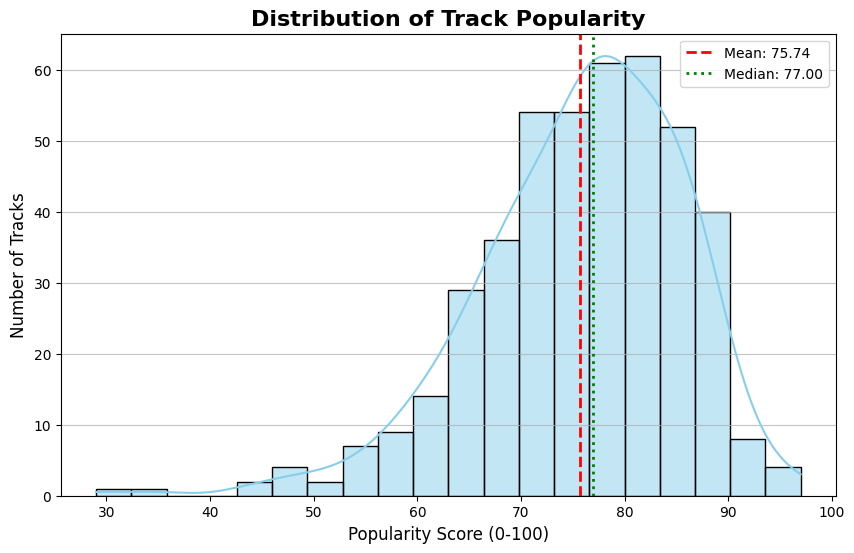

--- Popularity Distribution Summary Statistics ---
count    440.000000
mean      75.736364
std        9.886534
min       29.000000
25%       70.000000
50%       77.000000
75%       83.000000
max       97.000000
Name: Popularity, dtype: float64


In [17]:
#Q2.What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataframe
file_path = 'spotify.csv'
df = pd.read_csv(file_path)

# 1. Calculate descriptive statistics for the 'Popularity' column
popularity_stats = df['Popularity'].describe()

# 2. Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Popularity'], bins=20, kde=True, color='skyblue', edgecolor='black')

# Adding descriptive labels and title
plt.title('Distribution of Track Popularity', fontsize=16, fontweight='bold')
plt.xlabel('Popularity Score (0-100)', fontsize=12)
plt.ylabel('Number of Tracks', fontsize=12)
plt.grid(axis='y', alpha=0.75)

# Highlight the mean and median on the plot
mean_popularity = popularity_stats['mean']
median_popularity = popularity_stats['50%']
plt.axvline(mean_popularity, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_popularity:.2f}')
plt.axvline(median_popularity, color='green', linestyle='dotted', linewidth=2, label=f'Median: {median_popularity:.2f}')
plt.legend()

plt.show()

print("--- Popularity Distribution Summary Statistics ---")
print(popularity_stats)

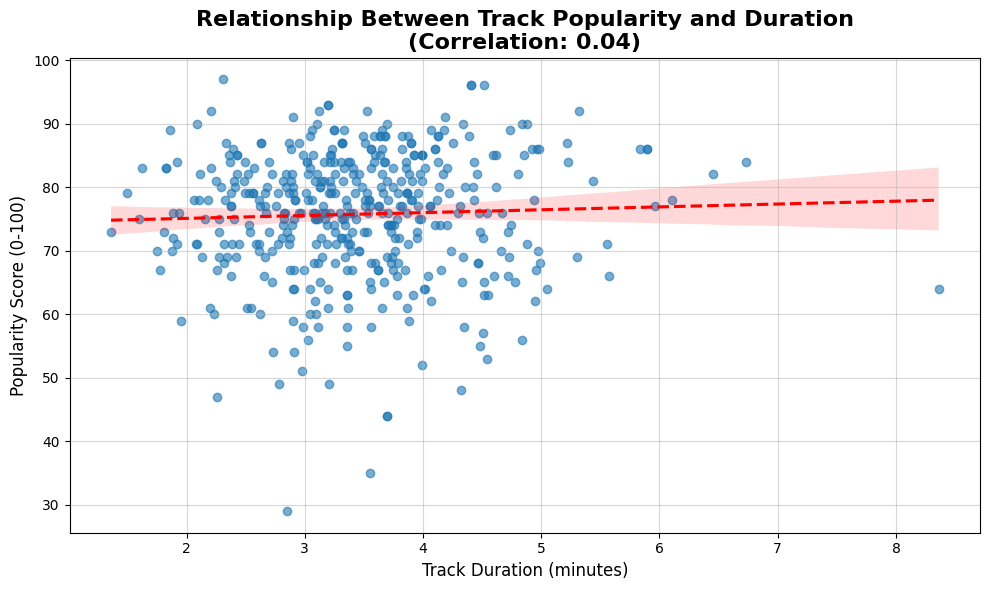

The Pearson correlation coefficient between Popularity and Duration (minutes) is: 0.04


In [18]:
#Q3.Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataframe
file_path = 'spotify.csv'
df = pd.read_csv(file_path)

# Convert Duration from milliseconds (ms) to minutes
df['Duration (minutes)'] = df['Duration (ms)'] / (1000 * 60)

# Calculate the Pearson correlation coefficient
correlation = df['Popularity'].corr(df['Duration (minutes)'])

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.regplot(
    x='Duration (minutes)',
    y='Popularity',
    data=df,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red', 'linestyle': '--'}
)

# Adding descriptive labels and title
plt.title(f'Relationship Between Track Popularity and Duration\n(Correlation: {correlation:.2f})', fontsize=16, fontweight='bold')
plt.xlabel('Track Duration (minutes)', fontsize=12)
plt.ylabel('Popularity Score (0-100)', fontsize=12)
plt.grid(axis='both', alpha=0.5)

plt.tight_layout()
plt.show() # In a real environment, this would be savefig
print(f"The Pearson correlation coefficient between Popularity and Duration (minutes) is: {correlation:.2f}")

/tmp/ipython-input-1222900795.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


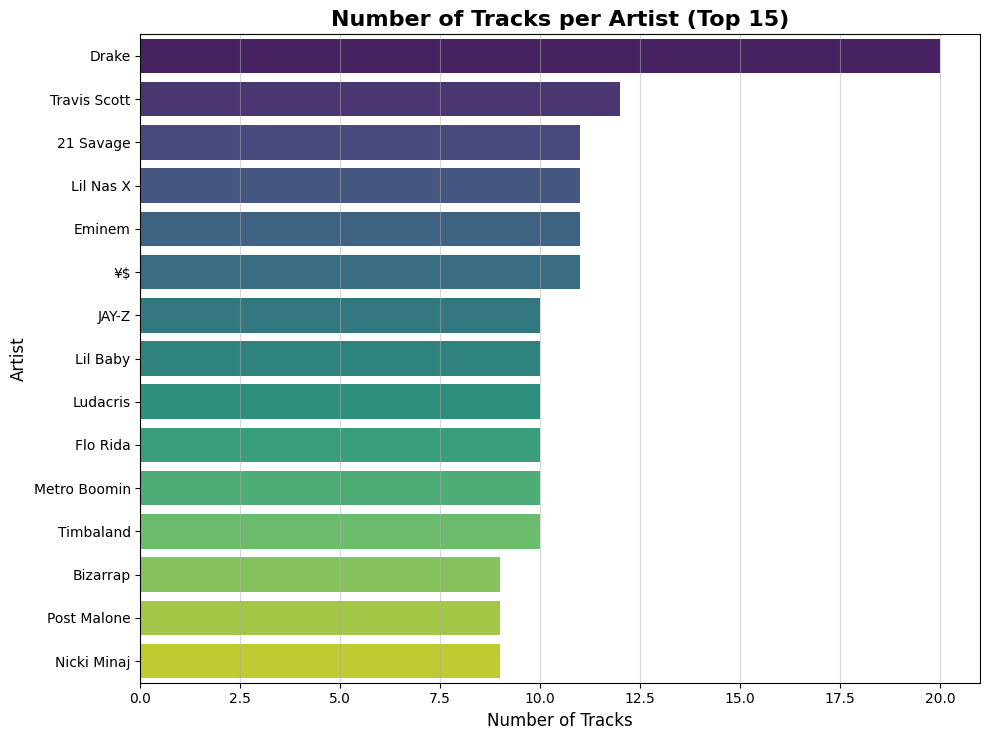

The artist with the highest number of tracks is: Drake with 20 tracks.

--- Full Track Counts per Artist ---
Artist
Drake           20
Travis Scott    12
21 Savage       11
Lil Nas X       11
Eminem          11
                ..
Lil Tjay         1
BigXthaPlug      1
Fat Joe          1
A$AP Ferg        1
Diddy            1
Name: count, Length: 115, dtype: int64


In [19]:
#Q4.Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataframe
file_path = 'spotify.csv'
df = pd.read_csv(file_path)

# 1. Calculate the number of tracks per artist
artist_counts = df['Artist'].value_counts()

# 2. Identify the artist with the highest number of tracks
top_artist = artist_counts.index[0]
top_artist_count = artist_counts.iloc[0]

# 3. Prepare data for plotting (using top 15 for visualization)
num_unique_artists = len(artist_counts)
artists_to_plot = artist_counts.head(min(15, num_unique_artists))

# Create the countplot (barplot)
plt.figure(figsize=(10, artists_to_plot.shape[0] * 0.5))
sns.barplot(
    y=artists_to_plot.index,
    x=artists_to_plot.values,
    palette='viridis',
    orient='h'
)

# Adding descriptive labels and title
plt.title(f'Number of Tracks per Artist (Top {len(artists_to_plot)})', fontsize=16, fontweight='bold')
plt.xlabel('Number of Tracks', fontsize=12)
plt.ylabel('Artist', fontsize=12)
plt.grid(axis='x', alpha=0.5)

plt.tight_layout()
plt.show() # In a real environment, this would be savefig
print(f"The artist with the highest number of tracks is: {top_artist} with {top_artist_count} tracks.")
print("\n--- Full Track Counts per Artist ---")
print(artist_counts)

In [20]:
#Q5.What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each.

import pandas as pd

# Load the dataframe
file_path = 'spotify.csv'
df = pd.read_csv(file_path)

# Sort the dataframe by 'Popularity' in ascending order
least_popular_tracks = df.sort_values(by='Popularity', ascending=True)

# Select the top 5 least popular tracks
top_5_least_popular = least_popular_tracks.head(5)

# Select and display the required columns
result = top_5_least_popular[['Artist', 'Track Name', 'Popularity']]

print(result.to_markdown(index=False))

| Artist         | Track Name                    |   Popularity |
|:---------------|:------------------------------|-------------:|
| Pressa         | Attachments (feat. Coi Leray) |           29 |
| Justin Bieber  | Intentions                    |           35 |
| French Montana | Splash Brothers               |           44 |
| French Montana | Splash Brothers               |           44 |
| Lil Baby       | On Me - Remix                 |           47 |


In [21]:
#Q6.Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist.

import pandas as pd

# Load the dataframe
file_path = 'spotify.csv'
df = pd.read_csv(file_path)

# 1. Identify the top 5 artists by track count
top_5_artists_names = df['Artist'].value_counts().head(5).index.tolist()

# 2. Filter the DataFrame to include only tracks by these top 5 artists
df_top_artists = df[df['Artist'].isin(top_5_artists_names)]

# 3. Calculate the average popularity for each of these artists
average_popularity = df_top_artists.groupby('Artist')['Popularity'].mean().sort_values(ascending=False)

# Display the result
print("Average Popularity for Each of the Top 5 Artists:")
print(average_popularity.round(2).to_markdown())

Average Popularity for Each of the Top 5 Artists:
| Artist       |   Popularity |
|:-------------|-------------:|
| Travis Scott |        87    |
| 21 Savage    |        84.18 |
| Eminem       |        83.64 |
| Drake        |        83.5  |
| Lil Nas X    |        76.09 |


In [22]:
#Q7.For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist.

import pandas as pd

# Load the dataframe
file_path = 'spotify.csv'
df = pd.read_csv(file_path)

# 1. Identify the top 5 artists by track count
top_5_artists_names = df['Artist'].value_counts().head(5).index.tolist()

# 2. Filter the DataFrame to include only tracks by these top 5 artists
df_top_artists = df[df['Artist'].isin(top_5_artists_names)]

# 3. Group by Artist and find the index of the track with the maximum Popularity for each artist
idx_max_popularity = df_top_artists.groupby('Artist')['Popularity'].idxmax()

# 4. Select the corresponding rows (the most popular track for each of the top 5 artists)
most_popular_tracks = df.loc[idx_max_popularity]

# 5. Select and sort the relevant columns for display
result = most_popular_tracks[['Artist', 'Track Name', 'Popularity']].sort_values(by='Popularity', ascending=False)

print(result.to_markdown(index=False))

| Artist       | Track Name                              |   Popularity |
|:-------------|:----------------------------------------|-------------:|
| 21 Savage    | redrum                                  |           96 |
| Travis Scott | FE!N (feat. Playboi Carti)              |           93 |
| Drake        | Rich Baby Daddy (feat. Sexyy Red & SZA) |           92 |
| Eminem       | Without Me                              |           90 |
| Lil Nas X    | THATS WHAT I WANT                       |           81 |


In [23]:
#Q8.For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist.

import pandas as pd

# Load the dataframe
file_path = 'spotify.csv'
df = pd.read_csv(file_path)

# 1. Identify the top 5 artists by track count
top_5_artists_names = df['Artist'].value_counts().head(5).index.tolist()

# 2. Filter the DataFrame to include only tracks by these top 5 artists
df_top_artists = df[df['Artist'].isin(top_5_artists_names)]

# 3. Group by Artist and find the index of the track with the maximum Popularity for each artist
idx_max_popularity = df_top_artists.groupby('Artist')['Popularity'].idxmax()

# 4. Select the corresponding rows (the most popular track for each of the top 5 artists)
most_popular_tracks = df.loc[idx_max_popularity]

# 5. Select and sort the relevant columns for display
result = most_popular_tracks[['Artist', 'Track Name', 'Popularity']].sort_values(by='Popularity', ascending=False)

print(result.to_markdown(index=False))

| Artist       | Track Name                              |   Popularity |
|:-------------|:----------------------------------------|-------------:|
| 21 Savage    | redrum                                  |           96 |
| Travis Scott | FE!N (feat. Playboi Carti)              |           93 |
| Drake        | Rich Baby Daddy (feat. Sexyy Red & SZA) |           92 |
| Eminem       | Without Me                              |           90 |
| Lil Nas X    | THATS WHAT I WANT                       |           81 |


/tmp/ipython-input-2626460664.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


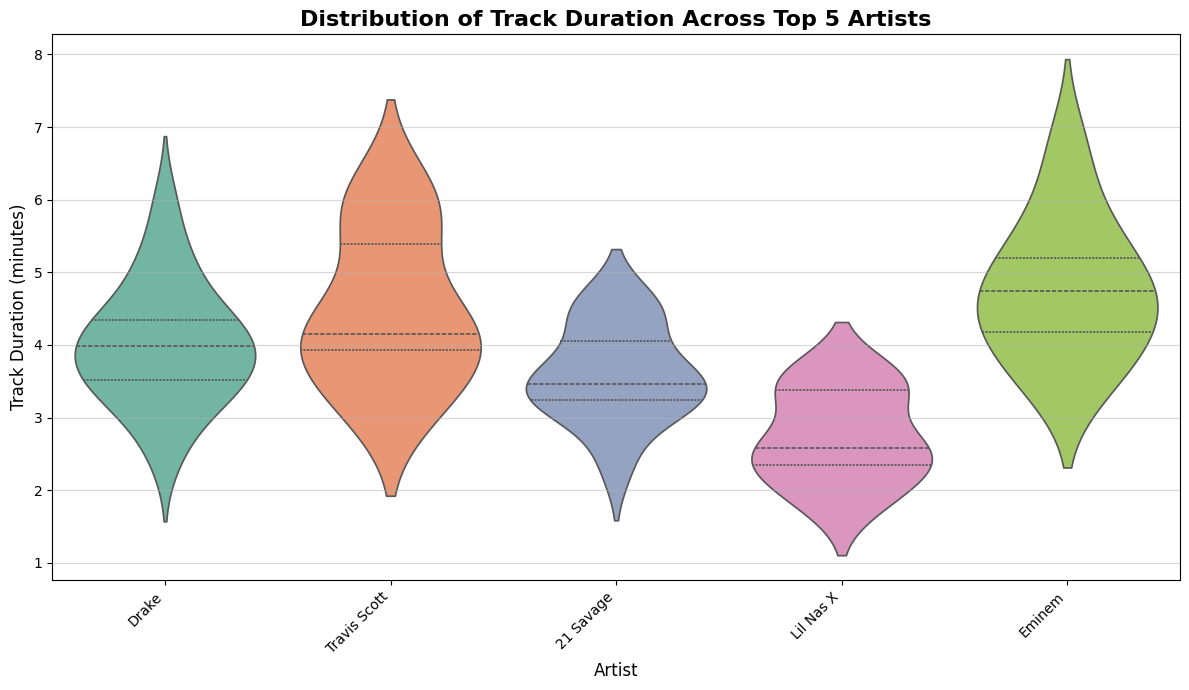

In [24]:
#Q9.Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataframe
file_path = 'spotify.csv'
df = pd.read_csv(file_path)

# 1. Identify the top 5 artists by track count
top_5_artists_names = df['Artist'].value_counts().head(5).index.tolist()

# 2. Filter the DataFrame to include only tracks by these top 5 artists
df_top_artists = df[df['Artist'].isin(top_5_artists_names)].copy()

# 3. Convert Duration from milliseconds (ms) to minutes
df_top_artists['Duration (minutes)'] = df_top_artists['Duration (ms)'] / (1000 * 60)

# 4. Create the violin plot
plt.figure(figsize=(12, 7))
sns.violinplot(
    x='Artist',
    y='Duration (minutes)',
    data=df_top_artists,
    palette='Set2',
    inner='quartile', # Show quartiles for better comparison
)

# Adding descriptive labels and title
plt.title('Distribution of Track Duration Across Top 5 Artists', fontsize=16, fontweight='bold')
plt.xlabel('Artist', fontsize=12)
plt.ylabel('Track Duration (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show() # In a real environment, this would be savefig

/tmp/ipython-input-3881474785.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


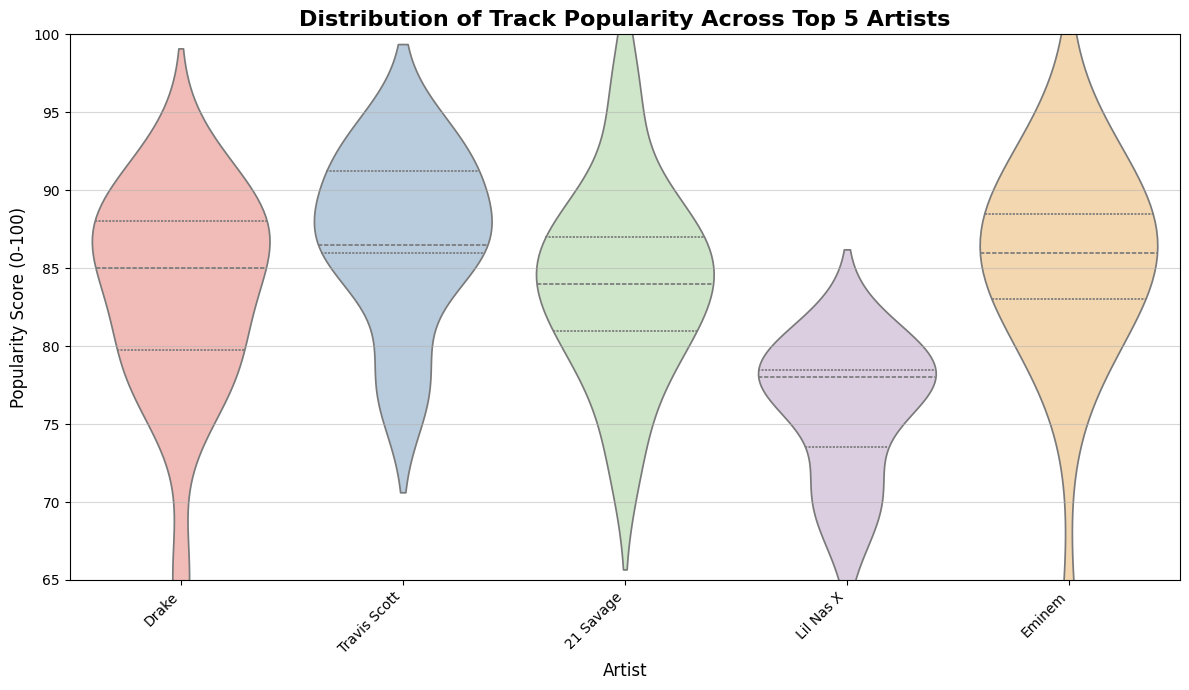

In [25]:
#Q10.How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataframe
file_path = 'spotify.csv'
df = pd.read_csv(file_path)

# 1. Identify the top 5 artists by track count
top_5_artists_names = df['Artist'].value_counts().head(5).index.tolist()

# 2. Filter the DataFrame to include only tracks by these top 5 artists
df_top_artists = df[df['Artist'].isin(top_5_artists_names)].copy()

# 3. Create the violin plot
plt.figure(figsize=(12, 7))
sns.violinplot(
    x='Artist',
    y='Popularity',
    data=df_top_artists,
    palette='Pastel1',
    inner='quartile',
)

# Adding descriptive labels and title
plt.title('Distribution of Track Popularity Across Top 5 Artists', fontsize=16, fontweight='bold')
plt.xlabel('Artist', fontsize=12)
plt.ylabel('Popularity Score (0-100)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.ylim(65, 100)

plt.tight_layout()
plt.show() # In a real environment, this would be savefig